# Fig. 5 Receptive-field plasticity: 수식 유도 + 플롯 + Brian2 연결

이 노트북의 목적은 **Fig. 5 결과 그림만 보여주는 것**이 아니라,

1. 어떤 입력이 들어가는지,
2. 그 입력이 NMDA/GABA current trace인 $E(t), I(t)$로 어떻게 변하는지,
3. $E(t), I(t)$가 excitatory/inhibitory plasticity rule에 어떻게 들어가는지,
4. 그 결과 왜 pathway 6을 중심으로 첫 번째 RF가 생기고, 이후 pathway 4 자극으로 RF가 재배열되는지

를 **단계별 플롯**으로 확인하는 것입니다.

논문 Fig. 5의 핵심 메시지는 다음입니다.

- 8개 pathway가 postsynaptic LIF neuron으로 들어온다.
- learning window에서는 inhibition이 줄어들어 excitatory plasticity gate가 열린다.
- 이때 강하게 활성화된 pathway는 Hebbian LTP로 강화된다.
- 동시에 heterosynaptic weakening 때문에 상대적으로 비활성 pathway는 약해진다.
- 이후 inhibitory plasticity는 $E/I$ balance에 맞추어 excitatory RF에 co-tuned된다.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("fig5_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

def save_and_show(fig, filename, dpi=300):
    """Save a figure to OUTDIR, display it in the notebook, and close it."""
    save_path = OUTDIR / filename

    if SAVE_FIGURES:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"saved: {save_path.resolve()}")

    plt.show()
    plt.close(fig)

rng = np.random.default_rng(1)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

print(f"Figure output directory: {OUTDIR.resolve()}")


Figure output directory: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs


## 1. Fig. 5에서 설명해야 하는 전체 흐름

Fig. 5는 단순히 receptive field profile을 얻는 그림이 아니라, 아래의 수식적 흐름을 보여주는 예입니다.


<p align="center">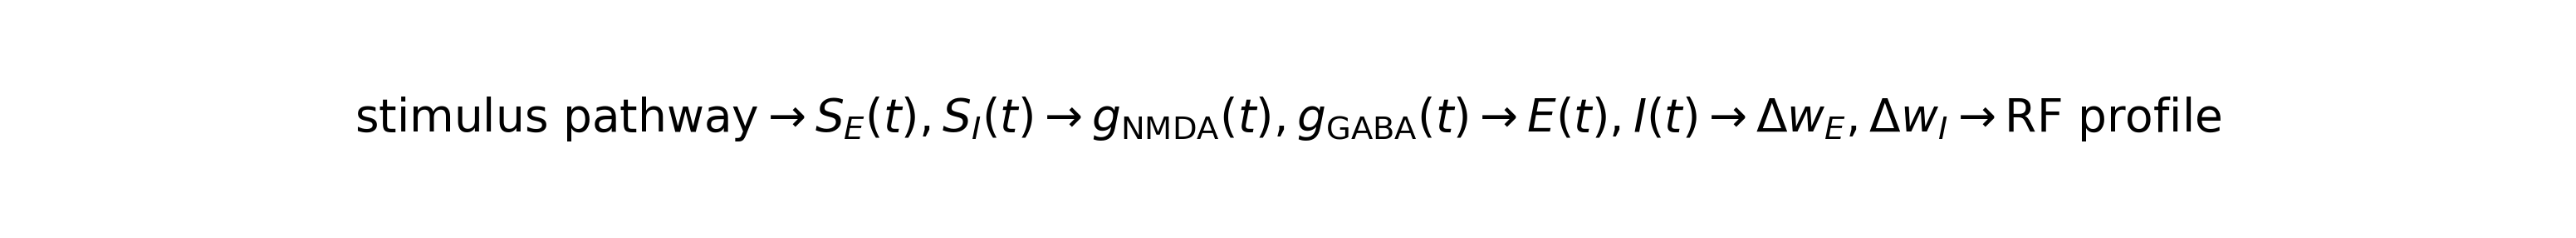</p>


발표에서는 이 흐름을 다음 순서로 보여주면 가장 안전합니다.

1. **Input pathway construction**: 8개 pathway, 각 pathway는 correlated E/I afferents.
2. **Disinhibition gate**: inhibition이 높으면 excitatory plasticity가 꺼지고, 낮으면 열린다.
3. **Excitatory update**: active pathway는 LTP, inactive pathway는 heterosynaptic LTD.
4. **Inhibitory update**: $E/I=\alpha$ balance setpoint로 inhibitory RF가 co-tuned된다.
5. **Two learning windows**: 첫 번째는 pathway 6 중심, 두 번째는 pathway 4 중심으로 RF 재배열.

## 2. 입력 pathway: OU fluctuation + learning-window burst

논문 Methods에서는 Fig. 5 receptive-field simulation에 8개 input pathway를 사용합니다. 각 pathway는 excitatory afferents와 inhibitory afferents를 포함하고, background firing과 OU fluctuation을 갖습니다.

간단화하면 pathway $\mu$의 입력 확률은 다음처럼 쓸 수 있습니다.


<p align="center">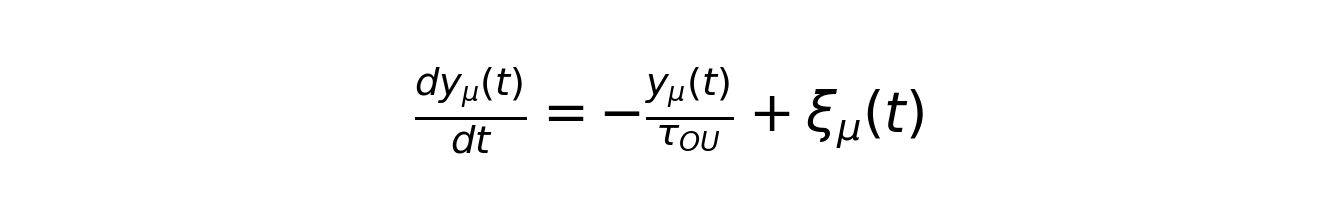</p>



<p align="center">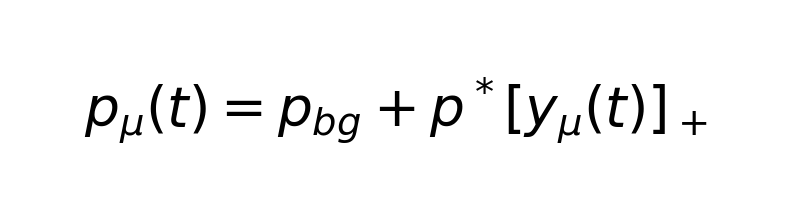</p>


여기서 $[x]_+=\max(x,0)$ 입니다. Fig. 5의 learning window에서는 특정 pathway를 중심으로 더 강한 burst input을 줍니다.

아래 플롯은 이 구조를 발표용으로 단순화해서 보여줍니다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs\01_input_protocol.png


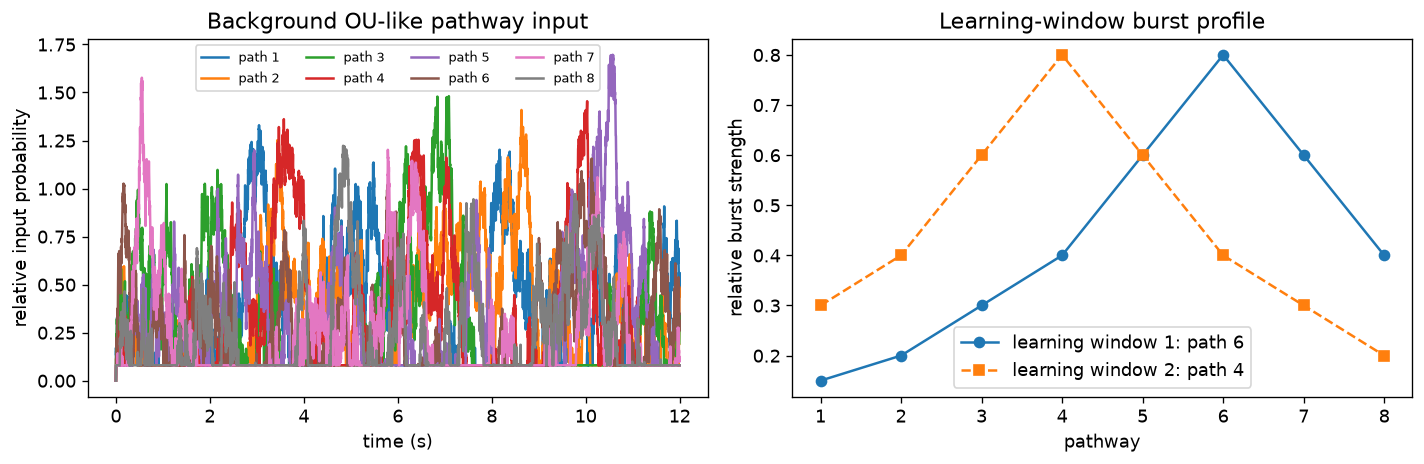

In [24]:
def simulate_ou_pathways(n_pathways=8, T=12.0, dt=0.002, tau_ou=0.5, amp=1.0, seed=3):
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    t = np.arange(n_steps) * dt
    y = np.zeros((n_steps, n_pathways))
    p = np.zeros_like(y)
    noise_scale = np.sqrt(dt)

    for i in range(1, n_steps):
        y[i] = y[i-1] + (-y[i-1] / tau_ou) * dt + rng.normal(0, 1, n_pathways) * noise_scale
        p[i] = 0.08 + amp * np.maximum(y[i], 0.0)

    return t, y, p


def burst_profile(center, n_pathways=8):
    # Similar to receptive_field_brian2.py mode='bn': strongest at active pathway, decays with distance.
    props = []
    for pw in range(1, n_pathways + 1):
        dist = abs(pw - center)
        if dist == 0:
            prop = 0.8
        elif dist == 1:
            prop = 0.6
        elif dist == 2:
            prop = 0.4
        elif dist == 3:
            prop = 0.3
        elif dist == 4:
            prop = 0.2
        elif dist == 5:
            prop = 0.15
        else:
            prop = 0.0
        props.append(prop)
    return np.array(props)

# OU background example
t, y, p = simulate_ou_pathways()
pathways = np.arange(1, 9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in range(8):
    axes[0].plot(t, p[:, k], label=f'path {k+1}')
axes[0].set_title('Background OU-like pathway input')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('relative input probability')
axes[0].legend(ncol=4, fontsize=8)

rf1_input = burst_profile(center=6)
rf2_input = burst_profile(center=4)
axes[1].plot(pathways, rf1_input, marker='o', label='learning window 1: path 6')
axes[1].plot(pathways, rf2_input, marker='s', linestyle='--', label='learning window 2: path 4')
axes[1].set_title('Learning-window burst profile')
axes[1].set_xlabel('pathway')
axes[1].set_ylabel('relative burst strength')
axes[1].set_xticks(pathways)
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "01_input_protocol.png")

## 3. Conductance에서 current trace로: $E(t)$와 $I(t)$

논문에서 co-dependent plasticity의 핵심 변수는 synapse 주변의 excitatory/inhibitory current history입니다.

Excitatory trace는 NMDA current를 low-pass filter한 변수로 볼 수 있습니다.


<p align="center">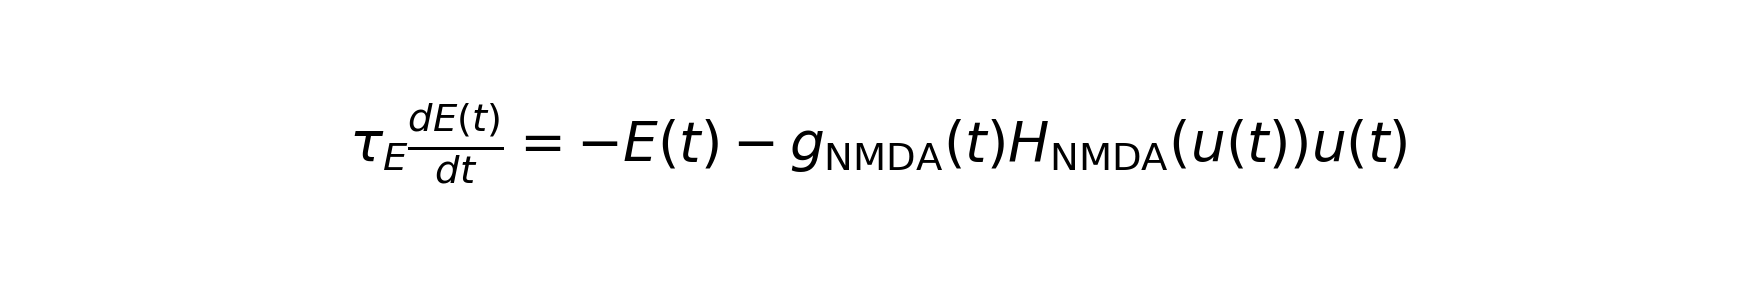</p>


Inhibitory trace는 GABAA current를 low-pass filter한 변수입니다.


<p align="center">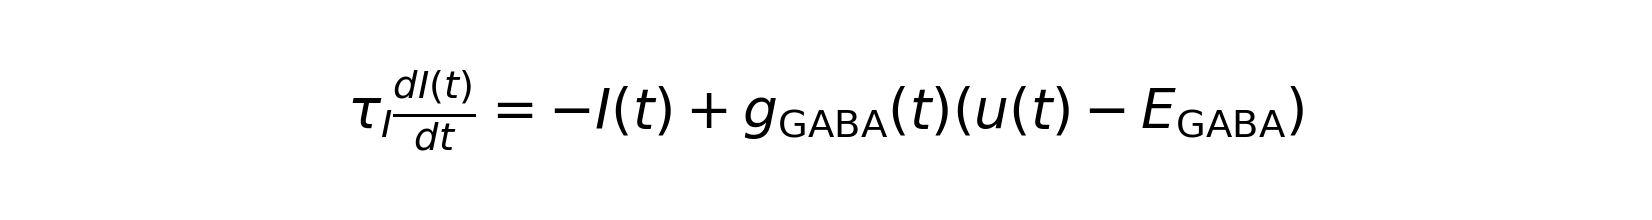</p>


NMDA current가 voltage-dependent인 이유는 Mg$^{2+}$ block을 나타내는 $H_{\mathrm{NMDA}}(u)$가 들어가기 때문입니다.


<p align="center">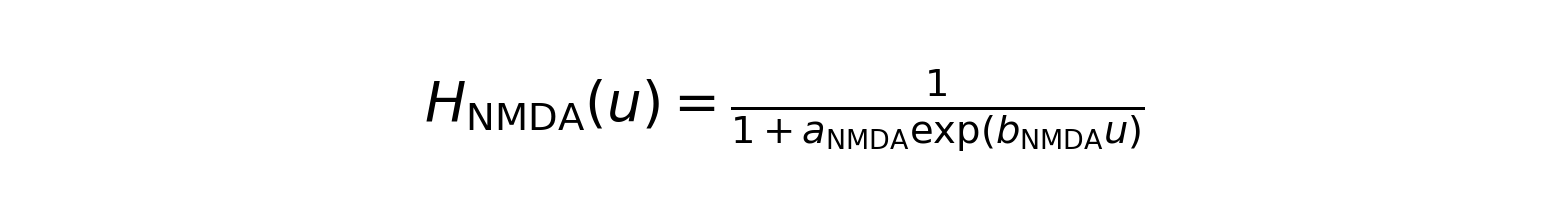</p>


아래는 $u$에 따른 NMDA gate와, spike train이 들어왔을 때 $E(t), I(t)$ trace가 어떻게 누적되는지 보여주는 플롯입니다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs\02_nmda_gate_and_current_trace.png


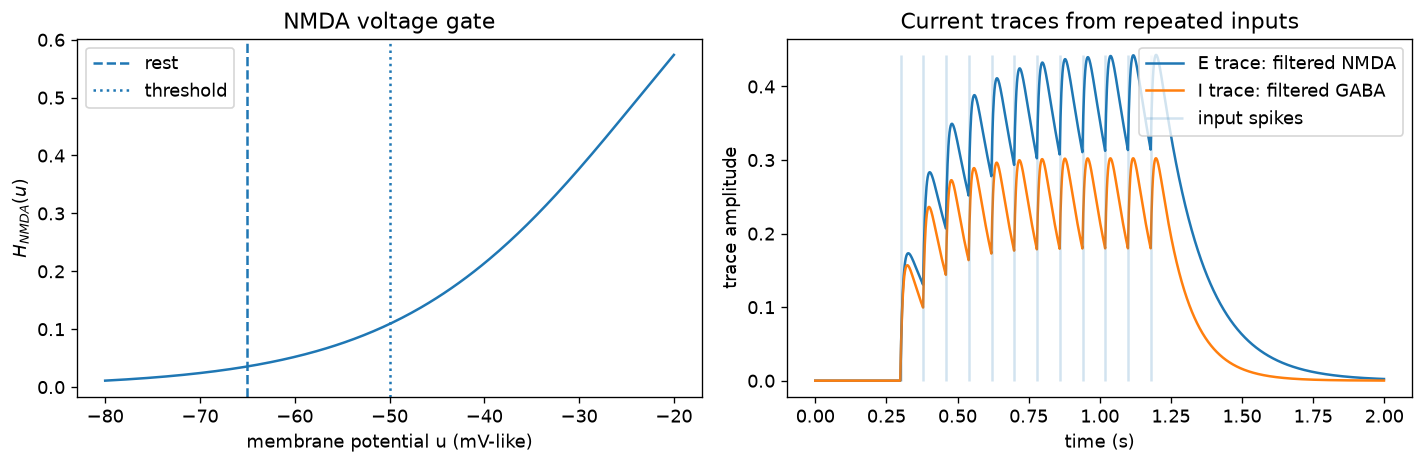

In [25]:
def H_nmda(u, a=0.15, b=-0.08):
    return 1.0 / (1.0 + a * np.exp(b * u))

u_grid = np.linspace(-80, -20, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(u_grid, H_nmda(u_grid))
axes[0].axvline(-65, linestyle='--', label='rest')
axes[0].axvline(-50, linestyle=':', label='threshold')
axes[0].set_title('NMDA voltage gate')
axes[0].set_xlabel('membrane potential u (mV-like)')
axes[0].set_ylabel(r'$H_{NMDA}(u)$')
axes[0].legend()

# Toy conductance traces from pathway spikes
T = 2.0
DT = 0.001
time = np.arange(int(T / DT)) * DT
spike_times = np.arange(0.3, 1.2, 0.08)
spikes = np.zeros_like(time)
for st in spike_times:
    spikes[np.argmin(np.abs(time - st))] = 1.0

tau_nmda = 0.150
tau_gaba = 0.010
tau_E = 0.010
tau_I = 0.100
u_const = -55.0
E_gaba = -80.0

g_nmda = np.zeros_like(time)
g_gaba = np.zeros_like(time)
E_trace = np.zeros_like(time)
I_trace = np.zeros_like(time)

for i in range(1, len(time)):
    g_nmda[i] = g_nmda[i-1] + DT * (-g_nmda[i-1] / tau_nmda) + 0.05 * spikes[i]
    g_gaba[i] = g_gaba[i-1] + DT * (-g_gaba[i-1] / tau_gaba) + 0.08 * spikes[i]
    nmda_current = -g_nmda[i] * H_nmda(u_const) * u_const
    gaba_current = g_gaba[i] * (u_const - E_gaba)
    E_trace[i] = E_trace[i-1] + DT * (-E_trace[i-1] + nmda_current) / tau_E
    I_trace[i] = I_trace[i-1] + DT * (-I_trace[i-1] + gaba_current) / tau_I

axes[1].plot(time, E_trace, label='E trace: filtered NMDA')
axes[1].plot(time, I_trace, label='I trace: filtered GABA')
axes[1].vlines(spike_times, 0, max(I_trace.max(), E_trace.max()), alpha=0.2, label='input spikes')
axes[1].set_title('Current traces from repeated inputs')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('trace amplitude')
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "02_nmda_gate_and_current_trace.png")

## 4. Excitatory plasticity: inhibition이 gate를 열고 닫는다

논문에서 excitatory synapse의 변화는 다음 형태입니다.


<p align="center">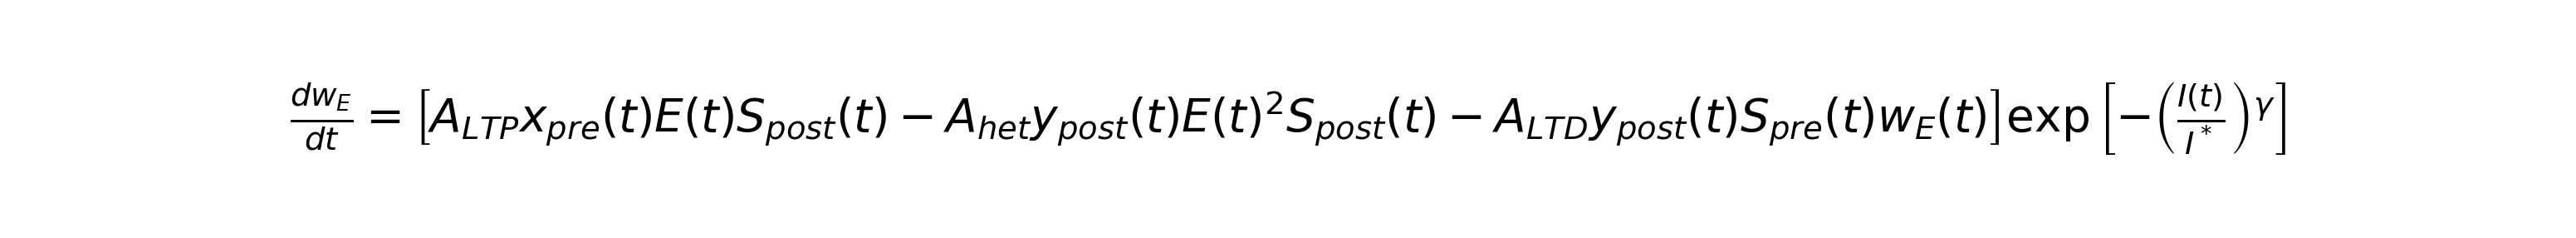</p>


여기서 마지막 exponential term이 **inhibitory gate**입니다.


<p align="center">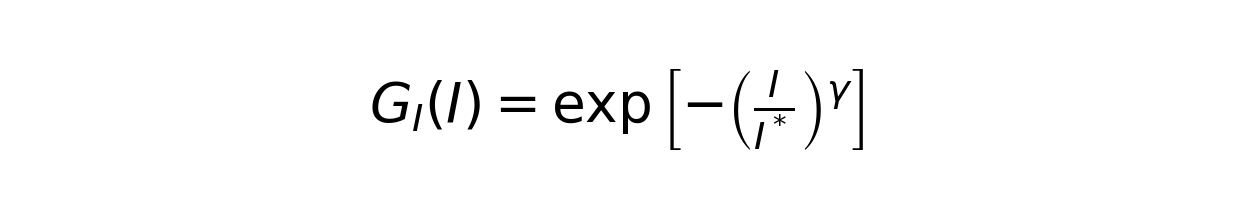</p>


- $I$가 크면 $G_I(I)\approx 0$: excitatory plasticity OFF.
- disinhibition으로 $I$가 작아지면 $G_I(I)\approx 1$: excitatory plasticity ON.

즉 Fig. 5의 learning window는 단순히 자극을 주는 구간이 아니라 **E plasticity gate가 열리는 구간**입니다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs\03_excitatory_plasticity_setpoint.png


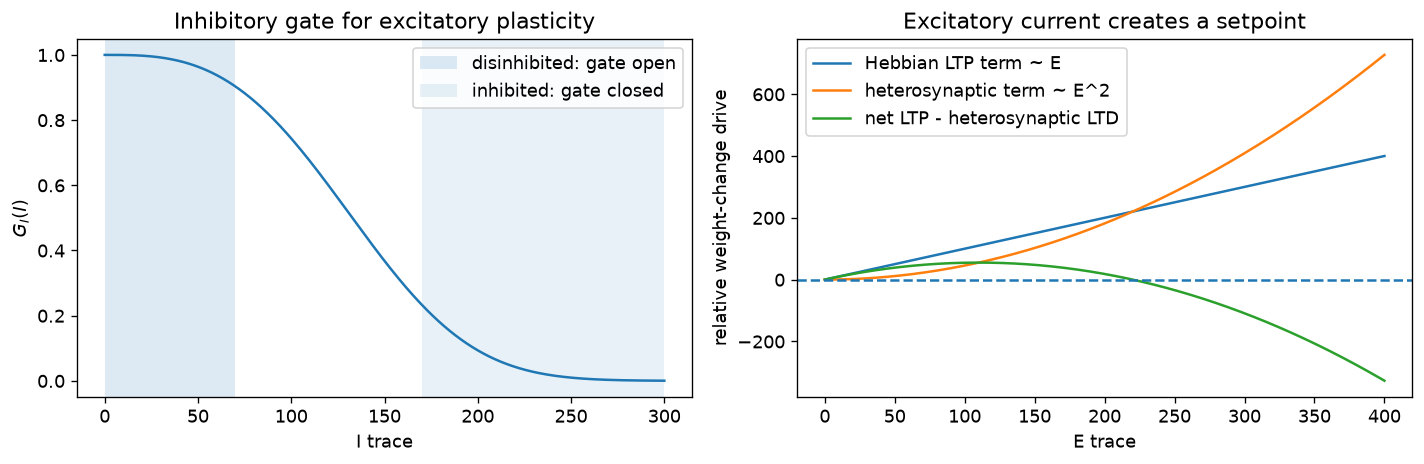

In [26]:
I = np.linspace(0, 300, 400)
I_star = 150.0
gamma = 3.0
gate = np.exp(-((I / I_star) ** gamma))

E = np.linspace(0, 400, 400)
A_ltp = 1.0
A_het = 1.0 / 220.0
ltp = A_ltp * E
het = A_het * E**2
net = ltp - het

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(I, gate)
axes[0].axvspan(0, 70, alpha=0.15, label='disinhibited: gate open')
axes[0].axvspan(170, 300, alpha=0.10, label='inhibited: gate closed')
axes[0].set_title('Inhibitory gate for excitatory plasticity')
axes[0].set_xlabel('I trace')
axes[0].set_ylabel(r'$G_I(I)$')
axes[0].legend()

axes[1].plot(E, ltp, label='Hebbian LTP term ~ E')
axes[1].plot(E, het, label='heterosynaptic term ~ E^2')
axes[1].plot(E, net, label='net LTP - heterosynaptic LTD')
axes[1].axhline(0, linestyle='--')
axes[1].set_title('Excitatory current creates a setpoint')
axes[1].set_xlabel('E trace')
axes[1].set_ylabel('relative weight-change drive')
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "03_excitatory_plasticity_setpoint.png")

## 5. Inhibitory plasticity: excitatory RF에 맞춰 co-tuning된다

Fig. 5에서는 inhibitory receptive field도 excitatory receptive field와 비슷한 profile로 서서히 맞춰집니다. 논문에서는 co-dependent inhibitory plasticity를 다음과 같이 씁니다.


<p align="center">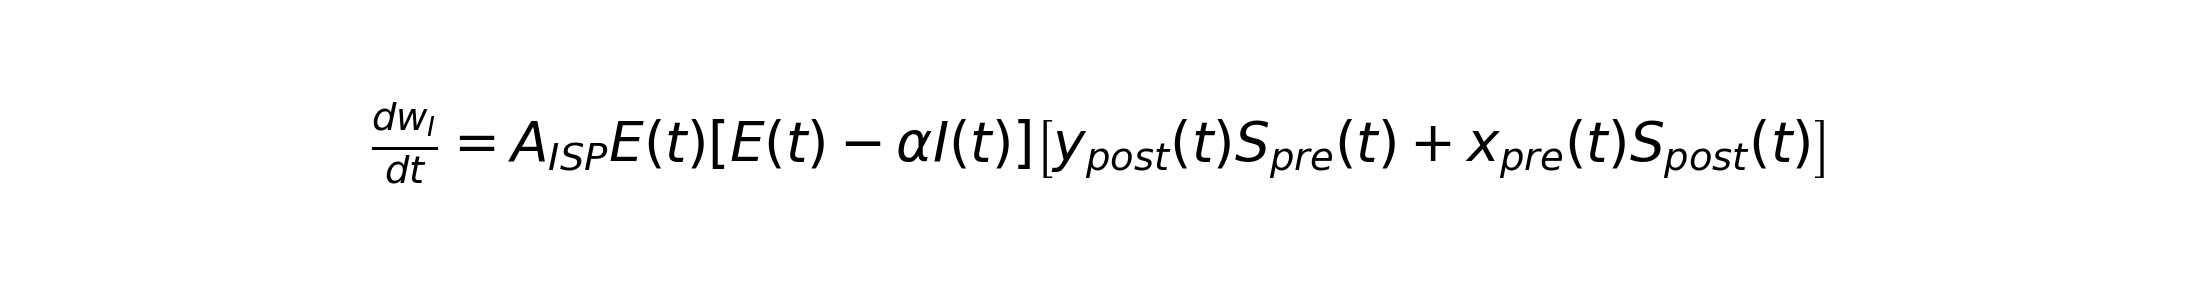</p>


핵심은 current-balance term입니다.


<p align="center">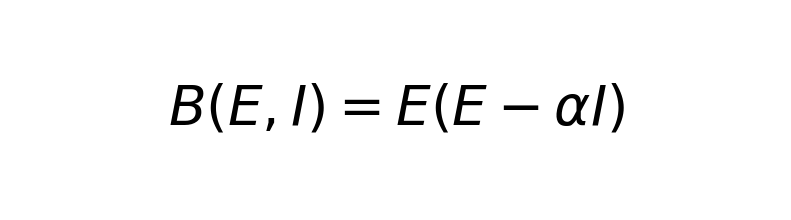</p>


- $E>\alpha I$: inhibition이 부족하므로 $w_I$ 증가.
- $E<\alpha I$: inhibition이 과하므로 $w_I$ 감소.
- $E=\alpha I$: fixed point, 즉 $E/I=\alpha$.

따라서 excitatory RF가 먼저 형성되면, inhibitory weight는 그 excitatory current profile을 따라 co-tuned됩니다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs\04_codependent_inhibitory_rule.png


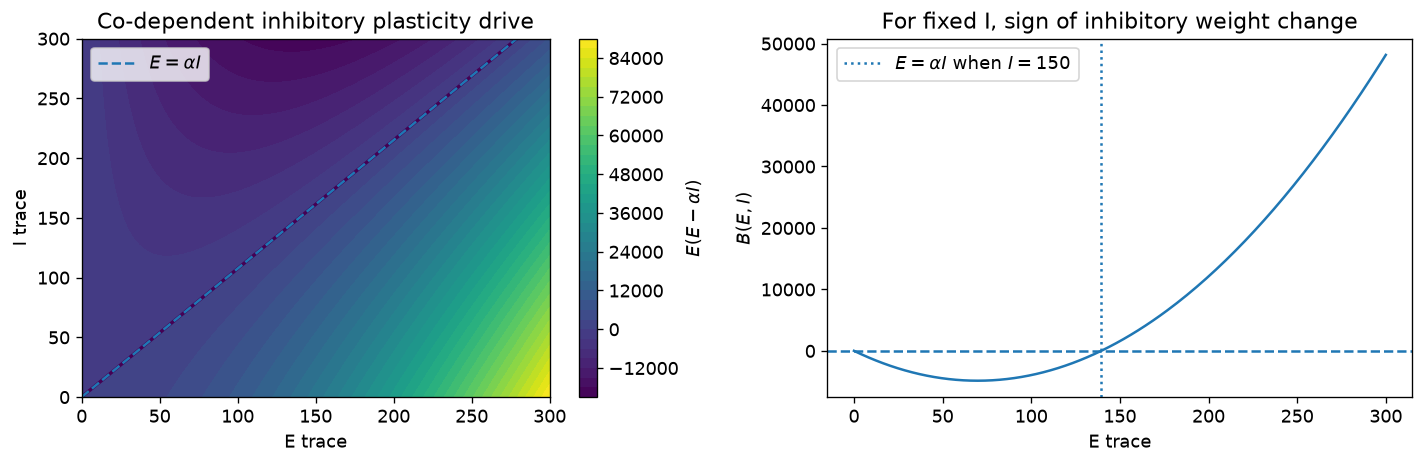

In [27]:
alpha = 0.93
E_vals = np.linspace(0, 300, 220)
I_vals = np.linspace(0, 300, 220)
EE, II = np.meshgrid(E_vals, I_vals)
B = EE * (EE - alpha * II)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cs = axes[0].contourf(EE, II, B, levels=40)
axes[0].contour(EE, II, B, levels=[0], linewidths=2)
axes[0].plot(I_vals * alpha, I_vals, linestyle='--', label=r'$E=\alpha I$')
axes[0].set_title('Co-dependent inhibitory plasticity drive')
axes[0].set_xlabel('E trace')
axes[0].set_ylabel('I trace')
axes[0].legend()
plt.colorbar(cs, ax=axes[0], label=r'$E(E-\alpha I)$')

ratio = E_vals / 150.0
balance_drive = E_vals * (E_vals - alpha * 150.0)
axes[1].plot(E_vals, balance_drive)
axes[1].axhline(0, linestyle='--')
axes[1].axvline(alpha * 150.0, linestyle=':', label=r'$E=\alpha I$ when $I=150$')
axes[1].set_title('For fixed I, sign of inhibitory weight change')
axes[1].set_xlabel('E trace')
axes[1].set_ylabel(r'$B(E,I)$')
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "04_codependent_inhibitory_rule.png")

## 6. Toy derivation: 왜 pathway 6 RF가 생기고, pathway 4로 바뀌는가?

아래는 Brian2 full simulation을 돌리기 전, 수식 흐름만 보이기 위한 **abstract RF update**입니다.

각 pathway $k$에 대해 activity profile $a_k$가 있다고 하면, learning window에서 대략 다음처럼 볼 수 있습니다.


<p align="center">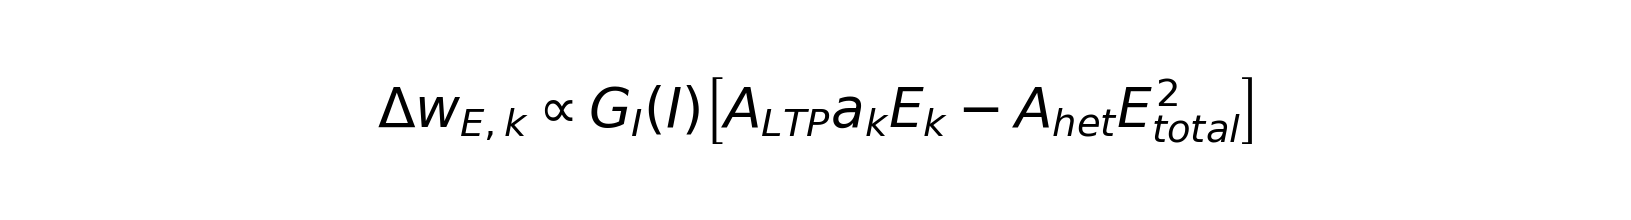</p>


- active pathway 근처: $a_k$가 커서 LTP가 우세.
- inactive pathway: heterosynaptic term 때문에 상대적으로 약화.
- inhibition이 높을 때: $G_I(I)$가 작아서 거의 변화 없음.

Inhibitory weight는 더 느린 timescale로 excitatory profile을 따라갑니다.


<p align="center">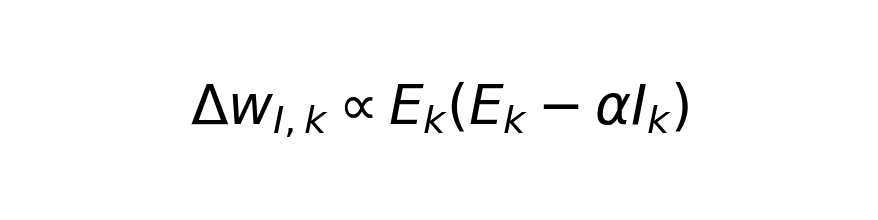</p>


발표에서는 이 toy plot으로 수식의 방향성을 먼저 보여주고, 그 다음 Brian2 simulation 결과를 보여주는 것이 좋습니다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig5_outputs\05_toy_receptive_field_learning.png


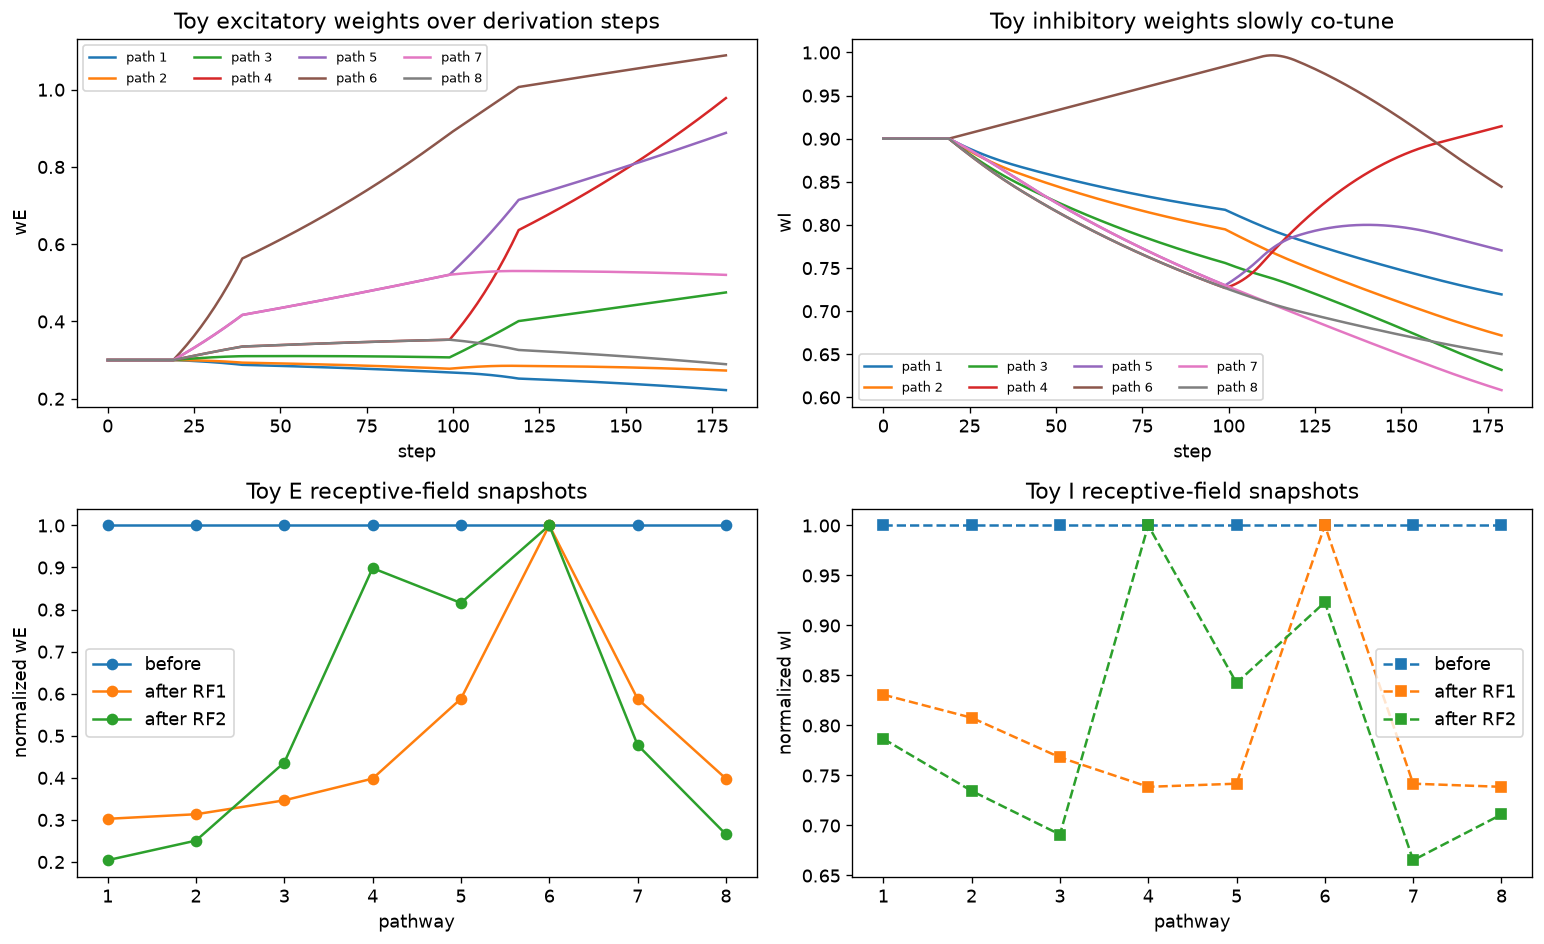

In [28]:
def normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    return x / (np.max(x) + eps)


def rf_learning_toy(n_pathways=8, center1=6, center2=4, steps_per_phase=80):
    pw = np.arange(1, n_pathways + 1)
    wE = np.ones(n_pathways) * 0.30
    wI = np.ones(n_pathways) * 0.90
    records = []

    def one_phase(center, phase_name):
        nonlocal wE, wI, records
        profile = burst_profile(center, n_pathways)
        profile = normalize(profile)
        for step in range(steps_per_phase):
            # Low inhibition during learning window means gate open.
            I_mean = 40.0 if step < 20 else 170.0
            gate = np.exp(-((I_mean / 150.0) ** 3.0))

            # E current roughly follows activity * weight.
            E_k = profile * wE
            E_total = np.sum(E_k)

            # Hebbian LTP for active inputs, heterosynaptic weakening for all inputs.
            ltp = 0.035 * profile * E_k
            het = 0.0035 * (E_total ** 2) * np.ones_like(wE) / n_pathways
            dwE = gate * (ltp - het)
            wE = np.clip(wE + dwE, 0.02, 1.2)

            # Inhibitory profile slowly follows E profile.
            E_norm = normalize(E_k)
            I_norm = normalize(wI)
            dwI = 0.015 * E_norm * (E_norm - 0.93 * I_norm)
            wI = np.clip(wI + dwI, 0.05, 2.0)

            records.append({
                'phase': phase_name,
                'step': len(records),
                'gate': gate,
                **{f'E{j+1}': wE[j] for j in range(n_pathways)},
                **{f'I{j+1}': wI[j] for j in range(n_pathways)},
            })

    # Stable baseline with gate mostly closed
    for step in range(20):
        records.append({
            'phase': 'baseline',
            'step': len(records),
            'gate': np.exp(-((180.0 / 150.0) ** 3.0)),
            **{f'E{j+1}': wE[j] for j in range(n_pathways)},
            **{f'I{j+1}': wI[j] for j in range(n_pathways)},
        })

    one_phase(center1, 'RF1: pathway 6')
    one_phase(center2, 'RF2: pathway 4')
    return pd.DataFrame(records)

toy = rf_learning_toy()

E_cols = [f'E{k}' for k in pathways]
I_cols = [f'I{k}' for k in pathways]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for k, col in enumerate(E_cols):
    axes[0, 0].plot(toy['step'], toy[col], label=f'path {k+1}')
axes[0, 0].set_title('Toy excitatory weights over derivation steps')
axes[0, 0].set_xlabel('step')
axes[0, 0].set_ylabel('wE')
axes[0, 0].legend(ncol=4, fontsize=8)

for k, col in enumerate(I_cols):
    axes[0, 1].plot(toy['step'], toy[col], label=f'path {k+1}')
axes[0, 1].set_title('Toy inhibitory weights slowly co-tune')
axes[0, 1].set_xlabel('step')
axes[0, 1].set_ylabel('wI')
axes[0, 1].legend(ncol=4, fontsize=8)

# Snapshots
snap_indices = [19, 99, len(toy)-1]
snap_labels = ['before', 'after RF1', 'after RF2']
for idx, label in zip(snap_indices, snap_labels):
    e = toy.loc[idx, E_cols].to_numpy(float)
    axes[1, 0].plot(pathways, normalize(e), marker='o', label=label)
axes[1, 0].set_title('Toy E receptive-field snapshots')
axes[1, 0].set_xlabel('pathway')
axes[1, 0].set_ylabel('normalized wE')
axes[1, 0].set_xticks(pathways)
axes[1, 0].legend()

for idx, label in zip(snap_indices, snap_labels):
    ii = toy.loc[idx, I_cols].to_numpy(float)
    axes[1, 1].plot(pathways, normalize(ii), marker='s', linestyle='--', label=label)
axes[1, 1].set_title('Toy I receptive-field snapshots')
axes[1, 1].set_xlabel('pathway')
axes[1, 1].set_ylabel('normalized wI')
axes[1, 1].set_xticks(pathways)
axes[1, 1].legend()

plt.tight_layout()
save_and_show(fig, "05_toy_receptive_field_learning.png")

## 7. 업로드한 Brian2 코드와 연결하기

업로드한 `receptive_field_brian2.py`는 아래 구조를 갖습니다.

- `ReceptiveFieldModel`: single postsynaptic neuron + 8 input pathways.
- `mode='g'`: OU-like background pathway input.
- `mode='h'`: homogeneous input.
- `mode='bn'`: RF burst input. `active_pw=6` 또는 `active_pw=4`로 learning window를 구현.
- `plasticity_e`: excitatory plasticity. inhibition gate, LTP, heterosynaptic term 포함.
- `plasticity_i`: inhibitory plasticity. `balance_signal = A_balance * E_trace * (E_trace - alpha_balance * I_trace)` 사용.
- `run_receptive_field_protocol`: RF1은 pathway 6, RF2는 pathway 4로 진행.

아래 셀은 Brian2가 설치되어 있을 때 실제 코드를 실행합니다. 시간이 오래 걸리면 `mode='quick'`부터 확인하고, 결과가 안정되면 `medium`, `fullish`로 올리면 됩니다.

In [29]:
RUN_BRIAN2 = False  # 실제 Brian2 simulation을 돌릴 때 True로 바꾸세요.
MODE = 'quick'      # 'quick', 'medium', or 'fullish'
SEED = 1

if RUN_BRIAN2:
    try:
        from receptive_field_brian2 import run_receptive_field_protocol, get_snapshot, records_to_arrays

        brian2_outdir = OUTDIR / f'brian2_{MODE}'
        model = run_receptive_field_protocol(mode=MODE, seed=SEED, outdir=brian2_outdir)

        rf1 = get_snapshot(model, 'rf1_final')
        rf2 = get_snapshot(model, 'rf2_final')
        times, firing, E_trace, I_trace, EI_ratio, E_paths, I_paths = records_to_arrays(model)
        times_min = times / 60.0

        print('RF1 final E profile:', np.round(rf1['E_norm'], 3))
        print('RF2 final E profile:', np.round(rf2['E_norm'], 3))
        print('RF1 final I profile:', np.round(rf1['I_norm'], 3))
        print('RF2 final I profile:', np.round(rf2['I_norm'], 3))

    except Exception as e:
        print('Brian2 run failed or Brian2 is not installed.')
        print(type(e).__name__, e)
else:
    print('RUN_BRIAN2=False: derivation cells only. Set RUN_BRIAN2=True to run uploaded Brian2 model.')

RUN_BRIAN2=False: derivation cells only. Set RUN_BRIAN2=True to run uploaded Brian2 model.


In [30]:
if RUN_BRIAN2 and 'model' in globals():
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].plot(pathways, rf1['E_norm'], marker='o', label='1st RF')
    axes[0, 0].plot(pathways, rf2['E_norm'], marker='s', linestyle='--', label='2nd RF')
    axes[0, 0].set_title('Brian2 excitatory RF profile')
    axes[0, 0].set_xlabel('pathway')
    axes[0, 0].set_ylabel('normalized weight')
    axes[0, 0].set_xticks(pathways)
    axes[0, 0].legend()

    axes[0, 1].plot(pathways, rf1['I_norm'], marker='o', label='1st RF')
    axes[0, 1].plot(pathways, rf2['I_norm'], marker='s', linestyle='--', label='2nd RF')
    axes[0, 1].set_title('Brian2 inhibitory RF profile')
    axes[0, 1].set_xlabel('pathway')
    axes[0, 1].set_ylabel('normalized weight')
    axes[0, 1].set_xticks(pathways)
    axes[0, 1].legend()

    for k in range(model.n_pw):
        axes[1, 0].plot(times_min, E_paths[:, k], label=f'path {k+1}')
    axes[1, 0].set_title('Brian2 E weights over time')
    axes[1, 0].set_xlabel('time (min)')
    axes[1, 0].set_ylabel('mean wE')
    axes[1, 0].legend(ncol=4, fontsize=8)

    for k in range(model.n_pw):
        axes[1, 1].plot(times_min, I_paths[:, k], label=f'path {k+1}')
    axes[1, 1].set_title('Brian2 I weights over time')
    axes[1, 1].set_xlabel('time (min)')
    axes[1, 1].set_ylabel('mean wI')
    axes[1, 1].legend(ncol=4, fontsize=8)

    plt.tight_layout()
    save_and_show(fig, f"06_brian2_receptive_field_profiles_and_weights_{MODE}.png")

In [31]:
if RUN_BRIAN2 and 'model' in globals():
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    axes[0].plot(times_min, firing)
    axes[0].set_title('Postsynaptic firing rate')
    axes[0].set_ylabel('Hz')

    axes[1].plot(times_min, E_trace, label='E trace')
    axes[1].plot(times_min, I_trace, label='I trace')
    axes[1].set_ylabel('trace')
    axes[1].legend()

    axes[2].plot(times_min, EI_ratio)
    axes[2].axhline(model.alpha_balance, linestyle='--', label='alpha balance')
    axes[2].set_title('E/I ratio')
    axes[2].set_xlabel('time (min)')
    axes[2].set_ylabel('E/I')
    axes[2].legend()

    plt.tight_layout()
    save_and_show(fig, f"07_brian2_firing_trace_and_ei_ratio_{MODE}.png")

## 8. 해석 문장

Fig. 5는 다음 한 문장으로 정리할 수 있습니다.

> Fig. 5에서 receptive field는 단순한 input selectivity plot이 아니라, disinhibition이 excitatory plasticity gate를 열고, 그 순간 active pathway가 Hebbian LTP로 강화되며, inactive pathway는 heterosynaptic weakening으로 약해지고, 이후 inhibitory plasticity가 $E/I=\alpha$ balance를 맞추면서 excitatory RF에 co-tuned되는 과정을 보여준다.

1. **입력 구조**: 8개 pathway, 각 pathway는 correlated E/I afferents.
2. **learning window**: inhibition downregulation으로 $G_I(I)$가 커짐.
3. **E plasticity**: active pathway는 LTP, inactive pathway는 heterosynaptic LTD.
4. **I plasticity**: $E(E-\alpha I)$ 항이 inhibitory weight를 조절해 E/I balance를 맞춤.
5. **결과**: pathway 6 중심 RF 형성 후, pathway 4 자극으로 RF가 재배열되고 inhibitory RF가 뒤따라 co-tuned됨.

다음 Fig. 6 notebook에서는 이 논리를 dendritic compartment로 옮겨서, co-active fraction과 soma-dendrite distance가 clustering index를 어떻게 바꾸는지 보여주면 됩니다.